In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
from curl_cffi import requests

In [ ]:
url = "https://www.sofascore.com/api/v1/event/15631372/shotmap"

In [ ]:
response = requests.get(url)

In [ ]:
response.status_code

200

In [ ]:
print(response.status_code)
print(response.json())

200
{'shotmap': [{'player': {'name': 'Christian Nørgaard', 'slug': 'christian-norgaard', 'shortName': 'C. Nørgaard', 'position': 'M', 'jerseyNumber': '16', 'userCount': 10149, 'gender': 'M', 'id': 135256, 'fieldTranslations': {'nameTranslation': {'ar': 'كريستيان نورغارد', 'bn': 'ক্রিশ্চিয়ান নরগার্ড', 'hi': 'क्रिश्चियन नॉरगार्ड'}, 'shortNameTranslation': {'ar': 'ك. نورغارد', 'bn': 'সি. নরগার্ড', 'hi': 'सी. नॉरगार्ड'}}}, 'isHome': True, 'shotType': 'save', 'situation': 'corner', 'playerCoordinates': {'x': 4.5, 'y': 64.6, 'z': 0}, 'bodyPart': 'head', 'goalMouthLocation': 'high-right', 'goalMouthCoordinates': {'x': 0, 'y': 47.4, 'z': 20.3}, 'blockCoordinates': {'x': 0.90000000000001, 'y': 53.6, 'z': 0}, 'xg': 0.015194706618786, 'xgot': 0.050190839916468, 'goalkeeper': {'name': 'Janis Blaswich', 'slug': 'janis-blaswich', 'shortName': 'J. Blaswich', 'position': 'G', 'jerseyNumber': '28', 'userCount': 702, 'gender': 'M', 'id': 96832, 'fieldTranslations': {'nameTranslation': {'ar': 'يانيس بلا

In [ ]:
data = response.json()
print(data.keys())

dict_keys(['shotmap'])


In [ ]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Christian Nørgaard', 'slug': 'christ...    True     save   
1  {'name': 'Ibrahim Maza', 'slug': 'maza-ibrahim...   False     miss   
2  {'name': 'Christian Kofane', 'firstName': 'Chr...   False     save   
3  {'name': 'Christian Kofane', 'firstName': 'Chr...   False     miss   
4  {'name': 'Bukayo Saka', 'slug': 'bukayo-saka',...    True     save   

  situation               playerCoordinates    bodyPart goalMouthLocation  \
0    corner   {'x': 4.5, 'y': 64.6, 'z': 0}        head        high-right   
1    corner    {'x': 19.7, 'y': 65, 'z': 0}  right-foot             right   
2  assisted  {'x': 10.5, 'y': 55.2, 'z': 0}   left-foot          low-left   
3  assisted  {'x': 24.6, 'y': 63.6, 'z': 0}  right-foot              left   
4  assisted  {'x': 10.1, 'y': 72.6, 'z': 0}  right-foot         low-right   

             goalMouthCoordinates                            blockCoordinates  \
0  {'x': 0, 'y': 

In [ ]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s["xg"] for s in data["shotmap"]],
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

               player  team_home shot_type situation   body_part     x     y  \
0  Christian Nørgaard       True      save    corner        head   4.5  64.6   
1        Ibrahim Maza      False      miss    corner  right-foot  19.7  65.0   
2    Christian Kofane      False      save  assisted   left-foot  10.5  55.2   
3    Christian Kofane      False      miss  assisted  right-foot  24.6  63.6   
4         Bukayo Saka       True      save  assisted  right-foot  10.1  72.6   

         xg  minute  
0  0.015195      90  
1  0.019122      88  
2  0.222237      87  
3  0.023584      85  
4  0.033325      78  


In [ ]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Christian Nørgaard,True,save,corner,head,4.5,64.6,0.015195,90
1,Ibrahim Maza,False,miss,corner,right-foot,19.7,65.0,0.019122,88
2,Christian Kofane,False,save,assisted,left-foot,10.5,55.2,0.222237,87
3,Christian Kofane,False,miss,assisted,right-foot,24.6,63.6,0.023584,85
4,Bukayo Saka,True,save,assisted,right-foot,10.1,72.6,0.033325,78


In [ ]:
shots_df.to_csv("shots.csv", index=False)

In [ ]:
from google.colab import files
files.download("shots.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# number of shots per team

In [ ]:
shots_df.groupby("team_home")["shot_type"].count()

,shot_type
team_home,
False,9
True,21


# Insight
Arsenal F.C. recorded 21 shots compared to 9 from Bayer 04 Leverkusen, highlighting Arsenal's attacking dominance throughout the match.

# Total shots per player

In [ ]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                player  Total_Shots
0            Ben White            1
1          Bukayo Saka            5
2     Christian Kofane            3
3   Christian Nørgaard            1
4          Declan Rice            2
5         Eberechi Eze            3
6       Edmond Tapsoba            1
7    Exequiel Palacios            1
8    Gabriel Magalhães            2
9         Ibrahim Maza            2
10      Jarell Quansah            1
11    Leandro Trossard            5
12      Robert Andrich            1
13     Viktor Gyökeres            2


In [ ]:
import pandas as pd

data = {
    "Player": [
        "Ben White",
        "Bukayo Saka",
        "Christian Kofane",
        "Christian Nørgaard",
        "Declan Rice",
        "Eberechi Eze",
        "Edmond Tapsoba",
        "Exequiel Palacios",
        "Gabriel Magalhães",
        "Ibrahim Maza",
        "Jarell Quansah",
        "Leandro Trossard",
        "Robert Andrich",
        "Viktor Gyökeres"
    ],
    "Total_Shots": [1, 5, 3, 1, 2, 3, 1, 1, 2, 2, 1, 5, 1, 2]
}

df = pd.DataFrame(data)

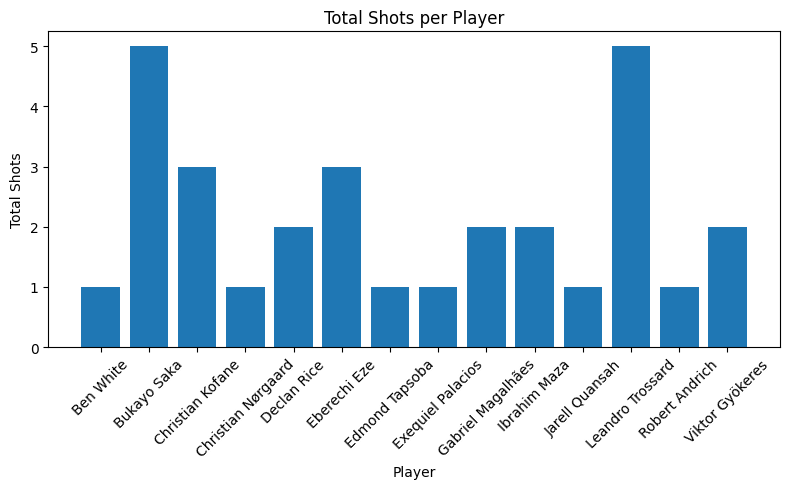

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Player"], df["Total_Shots"])

plt.title("Total Shots per Player")
plt.xlabel("Player")
plt.ylabel("Total Shots")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Insight
# Most Active Shooters

The players with the highest shot volume were:

Bukayo Saka – 5 shots

Leandro Trossard – 5 shots

# Insight:
Both players were the primary attacking outlets, leading all players in attempts on goal.

# Secondary Attacking Threats

Players with 3 shots:

Eberechi Eze – 3 shots

Christian Kofane – 3 shots

# Insight:
These players provided additional attacking support, suggesting the attack was not reliant on just one player.

3️⃣ Mid-Level Contributors

Players with 2 shots:

Declan Rice

Gabriel Magalhães

Ibrahim Maza

Viktor Gyökeres

🔎 Insight:
This indicates goal threat from multiple areas of the pitch, including midfield and defense.

4️⃣ Defensive Players Attempting Shots

Some defenders also recorded shots:

Ben White – 1

Edmond Tapsoba – 1

🔎 Insight:
Shots from defenders usually come from:

set pieces

corners

long-range attempts

5️⃣ Shot Distribution Insight

Total players taking shots: 14

Top 2 players (Saka & Trossard): 10 shots combined

If total shots ≈ 30, they produced about one-third of all attempts.

🔎 Insight:
This suggests the attacking play was concentrated around key forwards/wingers, with Saka and Trossard being heavily involved in the final third.

6️⃣ Tactical Interpretation

From the shot distribution:

Wide attackers generated the most attempts

Midfielders also contributed to attacking phases

Defenders joined attacks during set pieces

Overall conclusion:

Arsenal F.C. relied heavily on the attacking involvement of Bukayo Saka and Leandro Trossard, who led the match in shot attempts, while supporting contributions from midfielders helped maintain sustained attacking pressure against Bayer 04 Leverkusen.

# Separate the teams

In [ ]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

In [ ]:
home_shots.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Christian Nørgaard,True,save,corner,head,4.5,64.6,0.015195,90
4,Bukayo Saka,True,save,assisted,right-foot,10.1,72.6,0.033325,78
6,Bukayo Saka,True,save,assisted,head,2.4,59.6,0.147087,71
7,Eberechi Eze,True,block,fast-break,left-foot,13.3,45.6,0.237160,68
9,Declan Rice,True,goal,regular,right-foot,18.8,50.7,0.073276,63


In [ ]:
away_shots.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
1,Ibrahim Maza,False,miss,corner,right-foot,19.7,65.0,0.019122,88
2,Christian Kofane,False,save,assisted,left-foot,10.5,55.2,0.222237,87
3,Christian Kofane,False,miss,assisted,right-foot,24.6,63.6,0.023584,85
5,Jarell Quansah,False,miss,assisted,head,10.2,57.0,0.043322,77
8,Christian Kofane,False,miss,assisted,head,7.4,42.1,0.071410,66


# Team total Expected goals (xG)

In [ ]:
shots_df.groupby("team_home")["xg"].sum()

,xg
team_home,
False,0.519833
True,1.748399


# Key Insights
1️⃣ Arsenal Created Better Chances

Arsenal: 1.75 xG

Leverkusen: 0.52 xG

🔎 Insight:
Arsenal generated over three times the expected goal value of Leverkusen, meaning they produced higher-quality scoring opportunities.

2️⃣ Shot Volume vs Shot Quality

Earlier you found:

Arsenal: 21 shots

Leverkusen: 9 shots

Now combining this with xG:

Team	Shots	xG
Arsenal	21	1.75
Leverkusen	9	0.52

🔎 Interpretation

Arsenal had more shots AND better chances.

Leverkusen had few shots and low-quality opportunities.

This usually indicates territorial and attacking dominance.

3️⃣ Average Chance Quality

You can estimate xG per shot:

Arsenal: 1.75 / 21 ≈ 0.083 xG per shot

Leverkusen: 0.52 / 9 ≈ 0.058 xG per shot

🔎 Insight:
Arsenal not only shot more often but also created slightly better chances per attempt.

Tactical Interpretation

This pattern typically suggests:

Arsenal spent more time in the attacking third

Leverkusen likely relied on counterattacks or long-range shots

Arsenal likely created better chances inside the box

# number of situation per team

In [ ]:
# Count shots per situation for each team
situation_counts = shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation         
False      assisted              7
           corner                2
True       assisted              9
           corner                6
           fast-break            2
           regular               2
           free-kick             1
           throw-in-set-piece    1
Name: count, dtype: int64


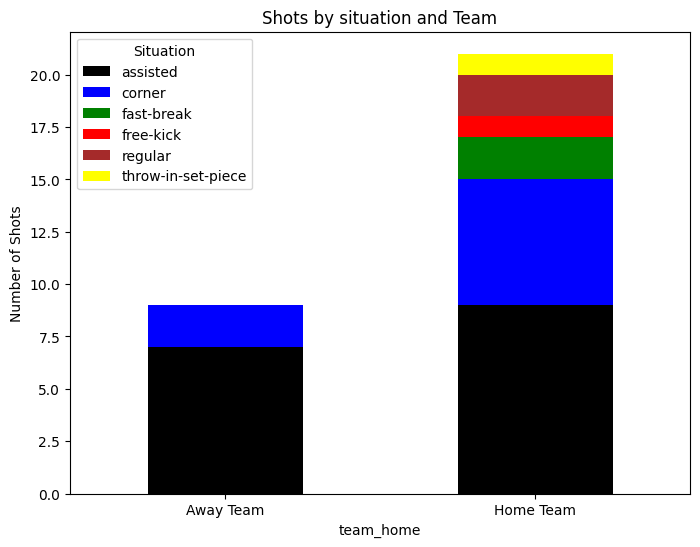

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "team_home": [False,False,True, True, True, True, True, True],
    "situation": ["assisted","corner","assisted","corner","fast-break","regular","free-kick","throw-in-set-piece"],
    "count": [7,2,9,6,2,2,1,1]
}

df = pd.DataFrame(data)

# Pivot for stacked bar chart
pivot_df = df.pivot(index='team_home', columns='situation', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, color=["black","blue","green","red", "brown", "yellow", "pink", "violet" ], figsize=(8,6))

plt.xticks(ticks=[0,1], labels=['Away Team','Home Team'], rotation=0)
plt.ylabel("Number of Shots")
plt.title("Shots by situation and Team")
plt.legend(title="Situation")
plt.show()

# Key Match Insights
1️⃣ Arsenal Created More Assisted Chances

Arsenal: 9 assisted shots

Leverkusen: 7 assisted shots

🔎 Insight:
This suggests Arsenal generated more structured attacking moves, where shots came from passes or build-up play rather than individual attempts.

2️⃣ Arsenal Had More Set-Piece Threat

Arsenal created shots from multiple set-piece situations:

Corners → 2

Free kicks → 2

Leverkusen had only:

Set-piece → 1

🔎 Insight:
Arsenal looked more dangerous from dead-ball situations, which could indicate strong delivery or aerial presence.

3️⃣ Leverkusen Relied More on Transitions

Fast-break shots:

Leverkusen → 1

Arsenal → 2

Even though Arsenal had slightly more, Leverkusen’s limited shot volume suggests they likely depended on counterattacks rather than sustained possession.

4️⃣ Arsenal Had a More Diverse Attack

Arsenal produced shots from five different situations:

Assisted

Corner

Fast-break

Free-kick

Regular play

Leverkusen only had three types.

🔎 Insight:
This indicates Arsenal had more varied attacking patterns, making them harder to defend.

Overall Tactical Interpretation

Combining all your earlier data:

Metric	Arsenal	Leverkusen
Shots	21	9
xG	1.75	0.52
Assisted shots	9	5

Conclusion:

Arsenal F.C. dominated the attacking phases of the match against Bayer 04 Leverkusen, generating significantly more shots and higher-quality chances. Most of Arsenal’s attempts came from assisted build-up play, highlighting effective chance creation through team combinations.

# Shots by body part

In [ ]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,17
head,7
left-foot,5
other,1


# Comparing shot and Expected goal

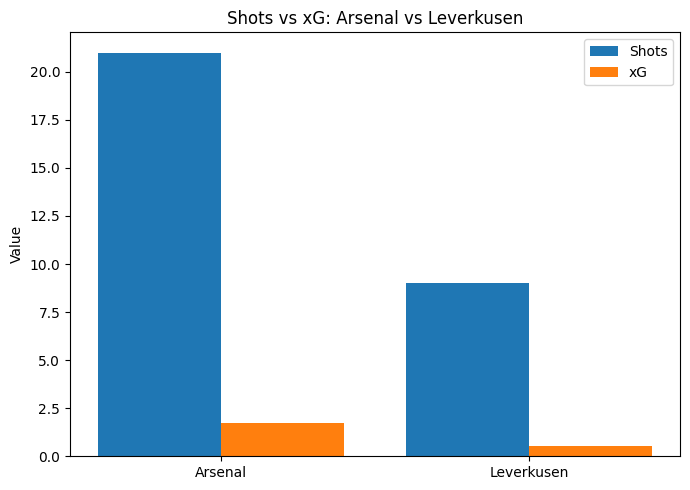

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["Arsenal", "Leverkusen"],
    "Shots": [21, 9],
    "xG": [1.75, 0.52]
}

df = pd.DataFrame(data)

x = range(len(df))

plt.figure(figsize=(7,5))

plt.bar(x, df["Shots"], width=0.4, label="Shots")
plt.bar([i + 0.4 for i in x], df["xG"], width=0.4, label="xG")

plt.xticks([i + 0.2 for i in x], df["Team"])
plt.ylabel("Value")
plt.title("Shots vs xG: Arsenal vs Leverkusen")
plt.legend()

plt.tight_layout()
plt.show()

# Most dangerous shooters

In [ ]:
shots_df.groupby("player")["xg"].sum().sort_values(ascending=False)

,xg
player,
Leandro Trossard,0.348331
Christian Kofane,0.317232
Bukayo Saka,0.309308
Eberechi Eze,0.298311
Ben White,0.290579
Gabriel Magalhães,0.261582
Viktor Gyökeres,0.113349
Declan Rice,0.111744
Ibrahim Maza,0.093923


# Plot shot map

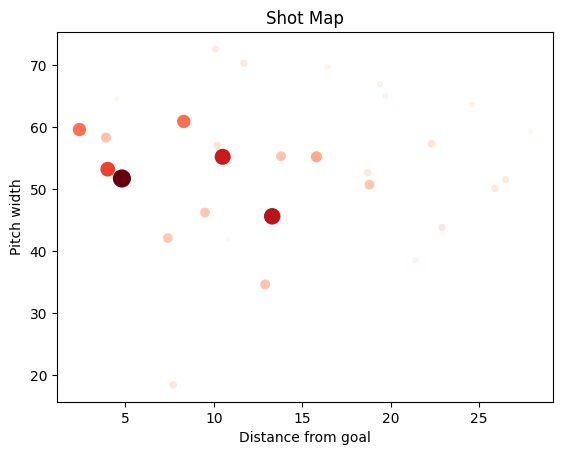

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(shots_df["x"], shots_df["y"], c=shots_df["xg"], s=shots_df["xg"]*500, cmap="Reds")
plt.xlabel("Distance from goal")
plt.ylabel("Pitch width")
plt.title("Shot Map")
plt.show()

In [ ]:
home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

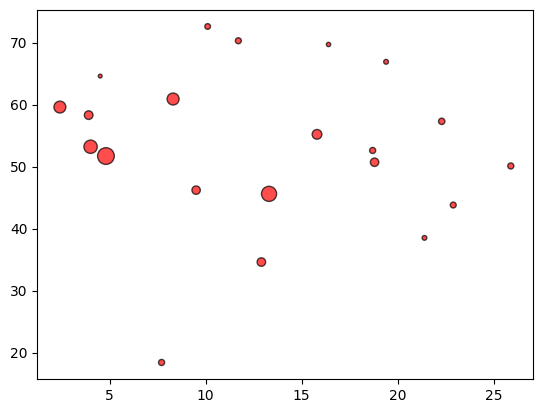

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(
    home["x"],
    home["y"],
    s=home["xg"]*500,
    c="red",
    edgecolor="black",
    alpha=0.7,
    label="Home Team"
)

# Plot the away team shots

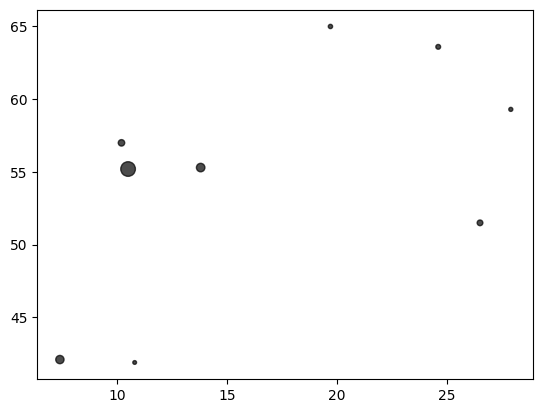

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(
    away["x"],
    away["y"],
    s=away["xg"]*500,
    c="black",
    edgecolor="black",
    alpha=0.7,
    label="Away Team"
)

In [ ]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.1 MB/s eta 0:00:00


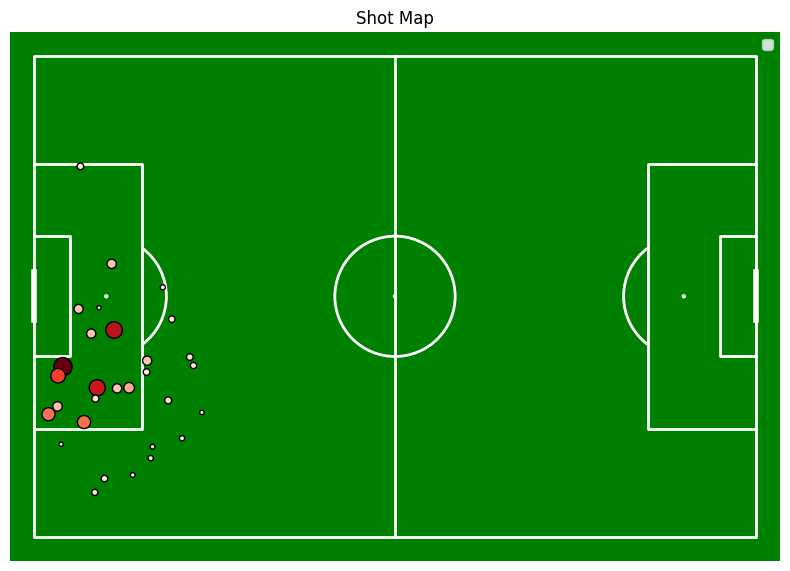

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    shots_df["x"],
    shots_df["y"],
    s=shots_df["xg"]*600,
    c=shots_df["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Shot Map")
plt.legend()
plt.show()

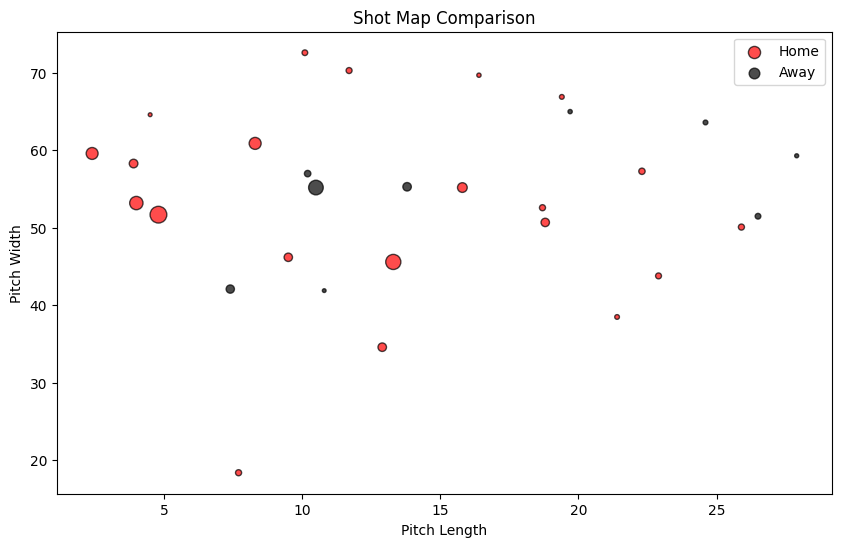

In [ ]:
plt.figure(figsize=(10,6))

home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

plt.scatter(home["x"], home["y"], s=home["xg"]*500,
            c="red", edgecolor="black", alpha=0.7, label="Home")

plt.scatter(away["x"], away["y"], s=away["xg"]*500,
            c="black", edgecolor="black", alpha=0.7, label="Away")

plt.title("Shot Map Comparison")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.legend()

plt.show()